<a href="https://colab.research.google.com/github/rajathikumaresan3-spec/Student-Performance-Analysic/blob/main/Student-Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                  STUDENT PERFORMANCE ANALYSIS REPORT                  
 Roll_No       Name  Maths  Physics  Chemistry  Total  Percentage Status           Grade  Rank
     101       Arun     85       78         90    253       84.33   Pass              A+   8.0
     102       Bala     42       50         38    130       43.33   Fail               F     -
     103      Divya     78       82         80    240       80.00   Pass              A+   9.0
     104    Kavitha     92       89         95    276       92.00   Pass O (Outstanding)   4.0
     105       Mani     35       40         45    120       40.00   Fail               F     -
     106      Priya     88       91         85    264       88.00   Pass              A+   6.0
     107      Rahul     65       70         62    197       65.67   Pass               B  13.0
     108   Santhosh     55       48         52    155       51.67   Fail               F     -
     109 Srinivasan     95       92         98    285       95.00   Pass 

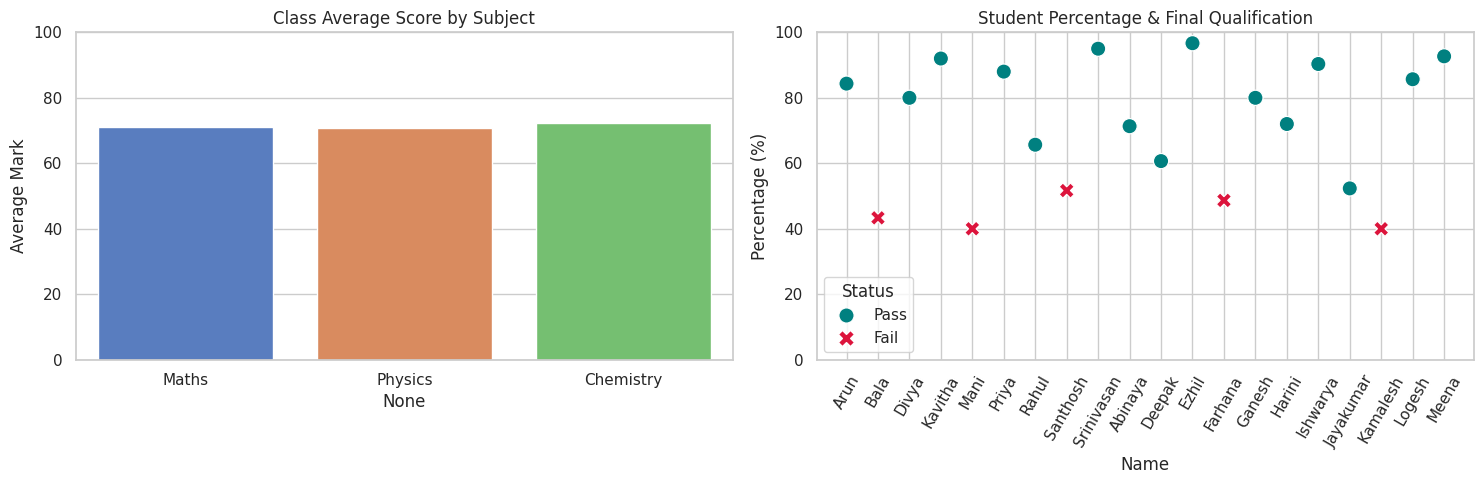

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Load the 20-student dataset directly inside Colab
raw_data = """Roll_No\tName\tMaths\tPhysics\tChemistry
101\tArun\t85\t78\t90
102\tBala\t42\t50\t38
103\tDivya\t78\t82\t80
104\tKavitha\t92\t89\t95
105\tMani\t35\t40\t45
106\tPriya\t88\t91\t85
107\tRahul\t65\t70\t62
108\tSanthosh\t55\t48\t52
109\tSrinivasan\t95\t92\t98
110\tAbinaya\t72\t68\t74
111\tDeepak\t60\t58\t64
112\tEzhil\t98\t95\t97
113\tFarhana\t45\t52\t49
114\tGanesh\t81\t76\t83
115\tHarini\t74\t70\t72
116\tIshwarya\t89\t92\t90
117\tJayakumar\t52\t50\t55
118\tKamalesh\t38\t42\t40
119\tLogesh\t87\t84\t86
120\tMeena\t93\t91\t94"""

# Read the data (handling tab separation from copy-paste)
df = pd.read_csv(io.StringIO(raw_data), sep="\t")


# 2. Function to compute pass/fail and grades
def calculate_grades(row):
    # Pass mark threshold set to 50
    if row["Maths"] < 50 or row["Physics"] < 50 or row["Chemistry"] < 50:
        return pd.Series(["Fail", "F"])
    else:
        status = "Pass"
        if row["Percentage"] >= 90:
            grade = "O (Outstanding)"
        elif row["Percentage"] >= 80:
            grade = "A+"
        elif row["Percentage"] >= 70:
            grade = "A"
        elif row["Percentage"] >= 60:
            grade = "B"
        else:
            grade = "C"
        return pd.Series([status, grade])


# 3. Process Data
subjects = ["Maths", "Physics", "Chemistry"]
df["Total"] = df[subjects].sum(axis=1)
df["Percentage"] = round(df["Total"] / len(subjects), 2)
df[["Status", "Grade"]] = df.apply(calculate_grades, axis=1)

# Add rank for students who passed (highest percentage gets Rank 1)
df["Rank"] = (
    df[df["Status"] == "Pass"]["Percentage"]
    .rank(ascending=False, method="min")
    .astype(float)
)
df["Rank"] = df["Rank"].fillna("-")  # Mark failed students with a dash

# 4. Display Outputs in Colab Cell
print("=" * 70)
print("                  STUDENT PERFORMANCE ANALYSIS REPORT                  ")
print("=" * 70)
print(df.to_string(index=False))
print("=" * 70)

print("\n📊 Subject Summary Metrics:")
print(df[subjects].describe().loc[["mean", "min", "max"]])

# 5. Save and Download the Results
output_filename = "student_performance_results.csv"
df.to_csv(output_filename, index=False)
print(f"\nSaved calculation matrix to {output_filename}")

# 6. Data Visualization
plt.figure(figsize=(15, 5))

# Plot 1: Subject performance comparison
plt.subplot(1, 2, 1)
means = df[subjects].mean()
sns.barplot(x=means.index, y=means.values, hue=means.index, legend=False, palette="muted")
plt.title("Class Average Score by Subject")
plt.ylabel("Average Mark")
plt.ylim(0, 100)

# Plot 2: Performance Distribution
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x="Name",
    y="Percentage",
    hue="Status",
    style="Status",
    s=120,
    palette={"Pass": "teal", "Fail": "crimson"},
)
plt.xticks(rotation=60)
plt.title("Student Percentage & Final Qualification")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("colab_performance_charts.png")
plt.show()

# Trigger automatic file download in your browser window
print("\nDownloading the final CSV report to your local computer...")
files.download(output_filename)